# Customer 360 EDA — Part 2: Customer Identity & Cross-Source Overlap

**Part 2 of 3** of the EDA. This notebook focuses on the **identity layer**: which fields can identify a customer, how complete/unique they are, how much the sources overlap, and how ready the dataset is for entity resolution and embedding-based text matching.

> Requirements from [`docs/eda-requirements.md`](../docs/eda-requirements.md). **We do not perform entity resolution here** — we provide the evidence needed to design it.

**Covered:**
1. Customer identity fields (completeness, uniqueness, stability)
2. Cross-source overlap (which sources share which customers)
3. Entity-resolution readiness (exact / normalized / fuzzy / semantic signals)
4. Text & embedding readiness


## 1. Setup & load

Same loading approach as Part 1. We reuse the single workbook.


In [1]:
import os, re, math, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200); pd.set_option("display.width", 200)

def _find_repo_root():
    p = Path.cwd()
    for _ in range(8):
        if (p / "data" / "raw" / "DATASET.xlsx").exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError("Could not locate repo root (data/raw/DATASET.xlsx) from " + str(Path.cwd()))

REPO = _find_repo_root()
RAW = REPO / "data" / "raw"
RAW = REPO / "data" / "raw"


def load_workbook(path):
    xl = pd.ExcelFile(path)
    return {name: xl.parse(name) for name in xl.sheet_names}

DATA = load_workbook(RAW / "DATASET.xlsx")
print("Sheets:", list(DATA.keys()))


Sheets: ['مشتریان', 'محصولات', 'فاکتورها', 'فروش', 'اجزای_هزینه_تحقق', 'وصول', 'شکایات', 'اتصال_شکایت', 'تعاملات_CRM', 'درخواست_توسعه', 'کیفیت_لات', 'همبافت_لات', 'آفرها', 'سهم_سبد', 'سیگنال_بازار', 'برآورد_هزینه_ماهانه']


## 2. Customer identity fields

Per the metadata, every customer-centric sheet links through **`Customer_ID`** to the `مشتریان` master. There are **no** name / company / email / phone / address columns (privacy note). Let's verify identity-field completeness, uniqueness and the consistency of the shared key.


In [2]:
# Which sheets carry Customer_ID and how many unique customers each covers
cust_cols = []
for name, df in DATA.items():
    if "Customer_ID" in df.columns:
        n = len(df); nu = df["Customer_ID"].nunique()
        cust_cols.append({"Sheet": name, "Records": n, "UniqueCustomers": nu,
                          "CoverageOfMaster%": round(nu / len(DATA["مشتریان"]) * 100, 2)})
cust_df = pd.DataFrame(cust_cols).sort_values("Records", ascending=False)
cust_df


,Sheet,Records,UniqueCustomers,CoverageOfMaster%
2,فروش,52987,644,100.00
3,وصول,15652,631,97.98
1,فاکتورها,14423,644,100.00
9,سهم_سبد,7488,624,96.89
6,تعاملات_CRM,4184,624,96.89
8,آفرها,2500,323,50.16
7,درخواست_توسعه,800,204,31.68
0,مشتریان,644,644,100.00
5,اتصال_شکایت,597,169,26.24
4,شکایات,520,169,26.24


In [3]:
# Is Customer_ID always populated & formatted consistently?
print("Customer_ID completeness & format per sheet:")
for name, df in DATA.items():
    if "Customer_ID" in df.columns:
        s = df["Customer_ID"]
        missing = s.isna().sum()
        # sample the format
        sample = s.dropna().astype(str).head(3).tolist()
        all_match = s.dropna().astype(str).str.match(r"^C_\d+$").mean() if s.notna().any() else float("nan")
        print(f"  {name:22s} missing={missing:5d} format_match%={all_match:.2f} sample={sample}")


Customer_ID completeness & format per sheet:
  مشتریان                missing=    0 format_match%=0.97 sample=['C_009817', 'C_010119', 'C_010649']
  فاکتورها               missing=    0 format_match%=1.00 sample=['C_703200', 'C_749821', 'C_310107']
  فروش                   missing=    0 format_match%=1.00 sample=['C_050237', 'C_317124', 'C_117580']
  وصول                   missing=    0 format_match%=1.00 sample=['C_703200', 'C_749821', 'C_310107']
  شکایات                 missing=    0 format_match%=0.92 sample=['CUST-003', 'CUST-010', 'CUST-019']
  اتصال_شکایت            missing=    0 format_match%=0.91 sample=['CUST-003', 'CUST-010', 'CUST-019']
  تعاملات_CRM            missing=    0 format_match%=1.00 sample=['C_009817', 'C_009817', 'C_009817']
  درخواست_توسعه          missing=    0 format_match%=1.00 sample=['C_683666', 'C_691869', 'C_939370']
  آفرها                  missing=    0 format_match%=1.00 sample=['C_746892', 'C_317124', 'C_683666']
  سهم_سبد                missing=    

In [4]:
# How many customers appear in exactly one source vs multiple (data-coverage of the universe)
master_ids = set(DATA["مشتریان"]["Customer_ID"])
per_source_sets = {n: set(df["Customer_ID"]) for n, df in DATA.items() if "Customer_ID" in df.columns}

union = set().union(*per_source_sets.values())
print(f"Master customers: {len(master_ids)}")
print(f"Customers appearing in >=1 source (union): {len(union)}")
print(f"Master customers that appear in NO other source: {len(master_ids - union)}")
print(f"Source-only customers not in master: {len(union - master_ids)}")


Master customers: 644
Customers appearing in >=1 source (union): 645
Master customers that appear in NO other source: 0
Source-only customers not in master: 1


## 3. Cross-source overlap

We measure, for every pair of customer-centric sources, how much their customer sets overlap (Jaccard on the shared `Customer_ID`). This is the key evidence for how connectable the sources are.


In [5]:
# Build an overlap matrix on Customer_ID (Jaccard similarity)
sources = [n for n in DATA if "Customer_ID" in DATA[n].columns]
sets = {n: set(DATA[n]["Customer_ID"]) for n in sources}
overlap = pd.DataFrame(index=sources, columns=sources, dtype=float)
for a in sources:
    for b in sources:
        if a == b:
            overlap.loc[a, b] = 1.0
        else:
            inter = len(sets[a] & sets[b])
            union = len(sets[a] | sets[b])
            overlap.loc[a, b] = round(inter / union, 3) if union else 0.0
overlap


,مشتریان,فاکتورها,فروش,وصول,شکایات,اتصال_شکایت,تعاملات_CRM,درخواست_توسعه,آفرها,سهم_سبد,سیگنال_بازار
مشتریان,1.000,1.000,1.000,0.980,0.262,0.262,0.969,0.317,0.502,0.969,0.088
فاکتورها,1.000,1.000,1.000,0.980,0.262,0.262,0.969,0.317,0.502,0.969,0.088
فروش,1.000,1.000,1.000,0.980,0.262,0.262,0.969,0.317,0.502,0.969,0.088
وصول,0.980,0.980,0.980,1.000,0.266,0.266,0.952,0.321,0.507,0.952,0.088
شکایات,0.262,0.262,0.262,0.266,1.000,1.000,0.231,0.424,0.378,0.231,0.091
اتصال_شکایت,0.262,0.262,0.262,0.266,1.000,1.000,0.231,0.424,0.378,0.231,0.091
تعاملات_CRM,0.969,0.969,0.969,0.952,0.231,0.231,1.000,0.327,0.518,1.000,0.091
درخواست_توسعه,0.317,0.317,0.317,0.321,0.424,0.424,0.327,1.000,0.493,0.327,0.074
آفرها,0.502,0.502,0.502,0.507,0.378,0.378,0.518,0.493,1.000,0.518,0.095
سهم_سبد,0.969,0.969,0.969,0.952,0.231,0.231,1.000,0.327,0.518,1.000,0.091


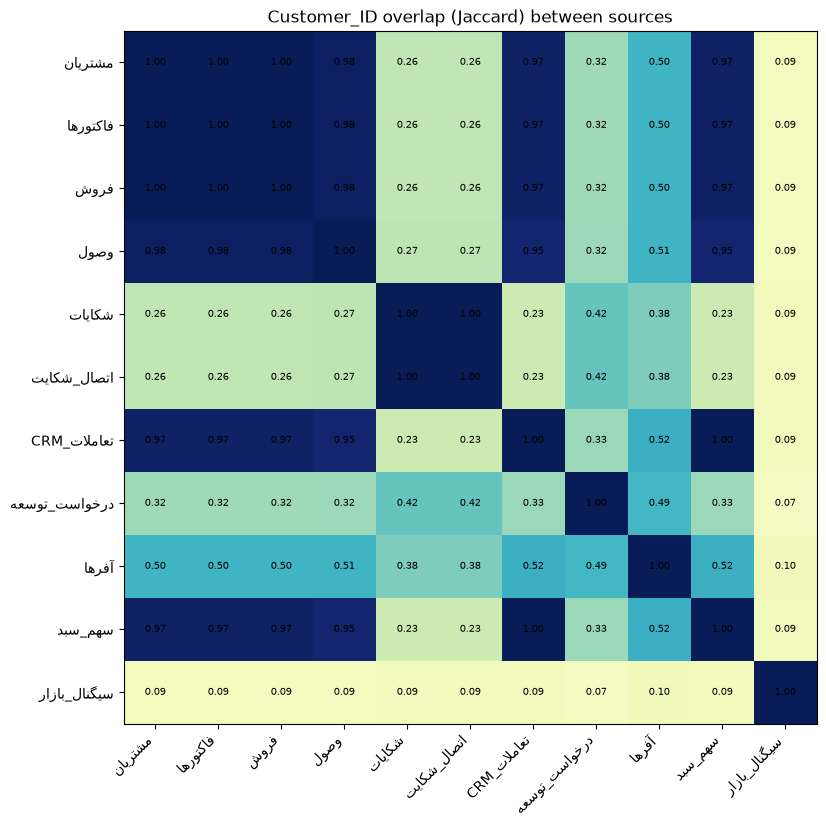

In [6]:
# Visualize the overlap matrix
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(overlap.values, cmap="YlGnBu", vmin=0, vmax=1)
ax.set_xticks(range(len(sources))); ax.set_xticklabels(sources, rotation=45, ha="right")
ax.set_yticks(range(len(sources))); ax.set_yticklabels(sources)
for i in range(len(sources)):
    for j in range(len(sources)):
        ax.text(j, i, f"{overlap.values[i,j]:.2f}", ha="center", va="center",
                color="black", fontsize=7)
ax.set_title("Customer_ID overlap (Jaccard) between sources")

plt.show()


In [7]:
# Pairwise linkable-record estimate using exact Customer_ID
print("Exact Customer_ID linkage between key sources (share of the smaller source's customers):")
key_pairs = [("فروش","مشتریان"), ("تعاملات_CRM","فروش"), ("شکایات","فروش"),
             ("شکایات","تعاملات_CRM"), ("درخواست_توسعه","فروش"), ("آفرها","فروش"),
             ("وصول","فروش"), ("سهم_سبد","فروش")]
for a, b in key_pairs:
    if a in sets and b in sets:
        inter = len(sets[a] & sets[b])
        print(f"  {a:18s} <-> {b:18s}: {inter} shared  ({inter/max(len(sets[a]),1)*100:.1f}% of {a})")


Exact Customer_ID linkage between key sources (share of the smaller source's customers):
  فروش               <-> مشتریان           : 644 shared  (100.0% of فروش)
  تعاملات_CRM        <-> فروش              : 624 shared  (100.0% of تعاملات_CRM)
  شکایات             <-> فروش              : 169 shared  (100.0% of شکایات)
  شکایات             <-> تعاملات_CRM       : 149 shared  (88.2% of شکایات)
  درخواست_توسعه      <-> فروش              : 204 shared  (100.0% of درخواست_توسعه)
  آفرها              <-> فروش              : 323 shared  (100.0% of آفرها)
  وصول               <-> فروش              : 631 shared  (100.0% of وصول)
  سهم_سبد            <-> فروش              : 624 shared  (100.0% of سهم_سبد)


## 4. Entity-resolution readiness

The key finding: **the dataset already shares a single canonical `Customer_ID` across essentially all sources.** So deterministic (exact) linking is already possible for a large fraction of records. We assess the remaining signals for the modeling stage.

### Strong signals (exact)
- `Customer_ID` — present and consistent across all customer-centric sheets.
- `Product_ID` — shared master key across sales / complaints / CRM / requests / offers / quality / costs.

### Medium signals
- None in the form of free-text identity (no name/company/email/phone). 

### Weak / semantic signals
- Free-text: `Complaint_Text`, `Resolution_Text`, CRM `Summary_Text`, `Requirement_Text`, market `Analysis`.


In [8]:
# Quantify exact-linkable records for a Customer 360 build
# Number of source rows that carry a Customer_ID (i.e. directly attachable)
linkable = sum(len(DATA[n]) for n in DATA if "Customer_ID" in DATA[n].columns)
total = sum(len(df) for df in DATA.values())
print(f"Rows carrying Customer_ID: {linkable} / {total} ({linkable/total*100:.1f}%)")
print(f"Rows without Customer_ID: {total - linkable}  (product master, cost plan, market, hembaft)")


Rows carrying Customer_ID: 99925 / 140115 (71.3%)
Rows without Customer_ID: 40190  (product master, cost plan, market, hembaft)


## 5. Text & embedding readiness

We assess each free-text source: record count, text length, empty %, language, and samples. This informs whether semantic embeddings would add value later.


In [9]:
# Text columns inventory
text_cols = {
    "شکایات": ["Complaint_Title", "Complaint_Text", "Resolution_Text"],
    "تعاملات_CRM": ["Summary_Text"],
    "درخواست_توسعه": ["Requirement_Text", "Outcome_Text"],
    "سیگنال_بازار": ["Analysis"],
}
def text_stats(df, col):
    s = df[col].astype(str).replace("nan", np.nan)
    non_null = s.notna()
    lens = s[non_null].str.len()
    empt = int((s[non_null].str.strip() == "").sum())
    return {
        "Sheet": None, "Column": col, "NonNull": int(non_null.sum()),
        "Empty%": round(empt/non_null.sum()*100, 2) if non_null.sum() else 0,
        "AvgLen": round(lens.mean(), 1) if len(lens) else 0,
        "MedianLen": int(lens.median()) if len(lens) else 0,
    }
rows = []
for sheet, cols in text_cols.items():
    for c in cols:
        r = text_stats(DATA[sheet], c); r["Sheet"] = sheet; rows.append(r)
text_df = pd.DataFrame(rows)
text_df


,Sheet,Column,NonNull,Empty%,AvgLen,MedianLen
0,شکایات,Complaint_Title,520,0.0,15.8,16
1,شکایات,Complaint_Text,520,0.0,85.2,80
2,شکایات,Resolution_Text,374,0.0,283.5,311
3,تعاملات_CRM,Summary_Text,4184,0.0,102.8,101
4,درخواست_توسعه,Requirement_Text,800,0.0,84.6,91
5,درخواست_توسعه,Outcome_Text,553,0.0,34.5,38
6,سیگنال_بازار,Analysis,130,0.0,102.1,101


In [10]:
# Representative text samples (truncated)
for sheet, cols in text_cols.items():
    for c in cols:
        vals = DATA[sheet][c].dropna().astype(str).str.strip()
        vals = vals[vals != ""]
        if len(vals):
            print(f"--- {sheet} :: {c} (sample of {len(vals)}) ---")
            for v in vals.head(2):
                print("   ", v[:140].replace("\n", " "))
            print()


--- شکایات :: Complaint_Title (sample of 520) ---
    فیلامنت و پرز
    دوک دست دوم / خرابی دوک

--- شکایات :: Complaint_Text (sample of 520) ---
    نخ در بعضي جاها سيمي ميباشد و همچنين پرز  شديد نيز در بعضي بسته ها وجود دارد.اين مشکل تکراري ميباشد و قبلا هم وجود داشته و مشتري اعلام نموده
    استفاده از دوك دسته دوم و تيغ خورده درقسمت رزرو و كثيفي

--- شکایات :: Resolution_Text (sample of 374) ---
    ابتدا موضوع از داخل سازمان بررسی گردید و نظرات واحدهای مرتبط دریافت گردید با توجه به بررسی‌های انجام‌شده مشخص گردید که در زمان تولید این نخ،
    موضوع از داخل سازمان بررسی گردید و نظرات واحدهای مرتبط دریافت گردید طی بازدید میدانی واحد خدمات مشتریان، موضوع **«خرابی دوک» منتفی** اعلام ش

--- تعاملات_CRM :: Summary_Text (sample of 4184) ---
    مشتری برنامه تقریبی خرید دوره بعد را اعلام کرد. اقدام بعدی: جلسه قیمت؛ فوریت: عادی؛ کد پیگیری 0003.
    بازخورد کیفی مشتری دریافت و برای بررسی فنی ارجاع شد. اقدام بعدی: بدون اقدام؛ فوریت: عادی؛ کد پیگیری 0005.

--- درخواست_توسعه :: Requirement_Text (

In [11]:
# Language hint: presence of Persian characters
import re as _re
def has_persian(s):
    return bool(_re.search(r"[\u0600-\u06FF]", s))
for sheet, cols in text_cols.items():
    for c in cols:
        vals = DATA[sheet][c].dropna().astype(str)
        if len(vals):
            pct = vals.apply(has_persian).mean() * 100
            print(f"  {sheet} :: {c}: {pct:.0f}% rows contain Persian text")


  شکایات :: Complaint_Title: 100% rows contain Persian text
  شکایات :: Complaint_Text: 99% rows contain Persian text
  شکایات :: Resolution_Text: 100% rows contain Persian text
  تعاملات_CRM :: Summary_Text: 100% rows contain Persian text
  درخواست_توسعه :: Requirement_Text: 100% rows contain Persian text
  درخواست_توسعه :: Outcome_Text: 100% rows contain Persian text
  سیگنال_بازار :: Analysis: 100% rows contain Persian text


## 6. Conclusion of Part 2

- **A canonical `Customer_ID` already links nearly all sources** — the dataset is designed around a shared customer master, so a large share of records can be attached deterministically.
- **Cross-source overlap is high for sales/CRM** and meaningful but smaller for complaints / requests / offers.
- **Entity resolution for the Customer 360 MVP can rely primarily on exact `Customer_ID`** linking, with product/lot linkage for manufacturing/quality.
- **Text data exists** in complaints, CRM summaries, requests, and market analysis (mostly Persian) — good candidates for later semantic/embedding matching, but **not required to resolve customer identity** given the shared key.
- No PII/contact fields exist, so fuzzy name/email/phone matching is **not applicable** to this dataset.

We now proceed to **Part 3: Domain EDA & Customer 360** (sales, product, CRM, complaints, requests, and a preliminary customer-level view).
